In [1]:
# Parameters
name      = ""
fits_path = ""

In [2]:
# Parameters
name = "LVM-30Dor-6563_D17"
fits_path = "fits_ready/LVM-30Dor-6563_D17.fits"


In [3]:
import time
start_time = time.time()

In [4]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
import corner
import json
from astropy.io import fits
import lmfit
from lmfit.model import save_modelresult


In [5]:
# Add path to py_modules 
sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root
#import strucfunc                   
import bfunc
import bplot
from reduced_chi2 import make_weights, tune_relative_uncertainty
import fit_diagnostic_utils as fdu

In [6]:
with fits.open("fits_ready/" + name + ".fits") as hdul:
    hdr = hdul[0].header

#m3D      = hdul[0].header['M3D']
#ra       = hdul[0].header['RA']
sig      = hdul[0].header['SIG']
sig2     = hdul[0].header['SIG2']
s0       = hdul[0].header['S0']
#noise    = hdul[0].header['NOISE']
box_size = hdul[0].header['BOX_SIZE']
pc       = hdul[0].header['PC']
pix      = hdul[0].header['PIX']
line     = hdul[0].header['LINE']
binsize  = hdul[0].header['BINSIZE']

In [7]:
hdul.info()

Filename: fits_ready/LVM-30Dor-6563_D17.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      29   ()      


In [8]:
pc_per_arcsec = pc
data = name

In [9]:
from astropy.table import Table
t = Table.read(fits_path, hdu="TABLE")
data_in = t.to_pandas()


B        = np.array(data_in['Unweighted B(r)'])#[mask]
r        = np.array(10 ** np.array(data_in['log10 r']))#[mask]

# Fit and Confidence intervals

## Non-Linear Least-Squares Fitting

In [10]:
# Merging point

K = 5
r[K] = np.mean(r[: K + 1])
B[K] = np.mean(B[: K + 1])
r = r[K:]
B = B[K:]

In [11]:
# Define some scales for turning points in sf

r_local_peak = 2.5
r_local_minimum = 4.5

In [12]:
# Weights

#relative_uncertainty = 0.035
#weights = 1.0 / (relative_uncertainty * B)
#large_scale = r > 0.10 * box_size
#weights[large_scale] /= 2.0
#weights[:3] /= 2.0

#to_fit = r <= 0.15 * box_size
#to_fit = ~large_scale

In [13]:
# Weight configuration

weight_config = dict(
    large_scale_limit=0.35,
    fit_limit=0.5,
    large_scale_factor=2.0,
    first_points_factor=2.0,
    n_first_points=3,
)

initial_relative_uncertainty = 0.05

In [14]:
to_fit = r <= weight_config["fit_limit"] * box_size
large_scale = r > weight_config["large_scale_limit"] * box_size

In [15]:
model = lmfit.Model(bfunc.bfunc03s)
model.param_names

['r0', 'sig2', 'm', 's0', 'noise']

In [16]:
# Correlation length between 1/10 and 2 x box_size
model.set_param_hint("r0", value=0.1 * box_size, min=0.01 * box_size, max=1.0 * box_size)

# sig2 between 1/4 and 2 x max value of B(r)
#model.set_param_hint("sig2", value=0.5 * B.max(), min=0.25 * B.max(), max=2 * B.max())
model.set_param_hint("sig2", 
                     value = 0.50 * B[to_fit].max(), 
                     min   = 0.25 * B[to_fit].max(), 
                     max   = 2.00 * B[to_fit].max()) 

# m between 1/2 and 5/3
model.set_param_hint("m", value=1.0, min=0.5, max=2.0)

# Seeing RMS between 0.1 and 1.5 arcsec
model.set_param_hint(
    "s0", value=0.5 * pc_per_arcsec, min=0.1 * pc_per_arcsec, max=1.5 * pc_per_arcsec
)

# Noise cannot be much larger than smallest B(r)
model.set_param_hint("noise", value=0.5 * B.min(), min=0.0, max=3 * B.min())

# box_size is fixed
# model.set_param_hint("box_size", value=box_size, vary=False)

In [17]:
pd.DataFrame(model.param_hints)

,r0,sig2,m,s0,noise
value,16.426998,34.345881,1.0,0.121203,2.749776
min,1.642700,17.172940,0.5,0.024241,0.000000
max,164.269976,137.383522,2.0,0.363610,16.498658


In [18]:
#result = model.fit(B[to_fit], weights=weights[to_fit], r=r[to_fit])

In [19]:
def fit_function(r_fit, B_fit, weights_fit):
    return model.fit(
        B_fit,
        weights=weights_fit,
        r=r_fit,
    )


result, relative_uncertainty, history = tune_relative_uncertainty(
    fit_function,
    r,
    B,
    box_size,
    initial_relative_uncertainty=initial_relative_uncertainty,
    target_redchi_min=0.5,
    target_redchi_max=1.0,
    step_factor=1.15,
    **weight_config,
)

iter 00: relative_uncertainty = 0.05000, redchi = 1.5999
iter 01: relative_uncertainty = 0.05750, redchi = 1.2098
iter 02: relative_uncertainty = 0.06612, redchi = 0.9148
Accepted relative_uncertainty.


In [20]:
weights_fit, to_fit, weights, large_scale = make_weights(
    r,
    B,
    box_size,
    relative_uncertainty=relative_uncertainty,
    **weight_config,
)

print("Accepted relative_uncertainty:", relative_uncertainty)
print("Final reduced chi-square:", result.redchi)

Accepted relative_uncertainty: 0.06612499999999999
Final reduced chi-square: 0.9147657398935356


In [21]:
result

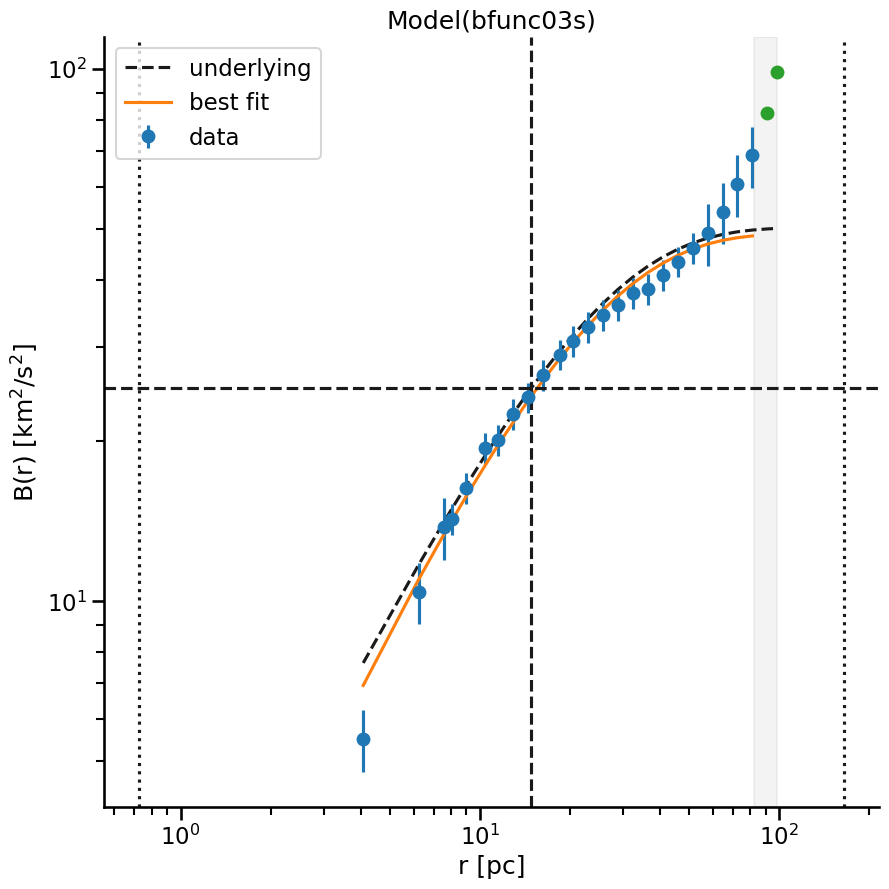

In [22]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the underlying model without instrumental effects
Bu = bfunc.bfunc00s(
    r, result.params["r0"].value, result.params["sig2"].value, result.params["m"].value
)
ax.plot(r, Bu, color="k", linestyle="dashed", label="underlying")

# Plot the fit results
result.plot_fit(ax=ax)

# Add in the points not included in fit
ax.plot(r[~to_fit], B[~to_fit], "o")

# Dotted lines for 2 x rms seeing and for box size
ax.axvline(2 * result.params["s0"].value, color="k", linestyle="dotted")
ax.axvline(box_size, color="k", linestyle="dotted")

# Dashed lines for best-fit r0 and sig2
ax.axvline(result.params["r0"].value, color="k", linestyle="dashed")
ax.axhline(result.params["sig2"].value, color="k", linestyle="dashed")

# Gray box to indicate the large scale values that are excluded from the fit
ax.axvspan(box_size / 2, r[-1], color="k", alpha=0.05, zorder=-1)

ax.set(
    xscale="log",
    yscale="log",
    xlabel="r [pc]",
    ylabel=r"B(r) [km$^{2}$/s$^{2}$]",
)
sns.despine()

## emcee

In [23]:
emcee_kws = dict(
    steps=35000, burn=1000, thin=50, is_weighted=True, progress=False, workers=1
)
emcee_params = result.params.copy()
# emcee_params.add('__lnsigma', value=np.log(0.1), min=np.log(0.001), max=np.log(2.0))

In [24]:
result_emcee = model.fit(
    data=B[to_fit],
    r=r[to_fit],
    weights=weights[to_fit],
    params=emcee_params,
    method="emcee",
    nan_policy="omit",
    fit_kws=emcee_kws,
)

/Users/javier/miniconda3/envs/viento/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [25]:
result_emcee

Text(0, 0.5, 'acceptance fraction')

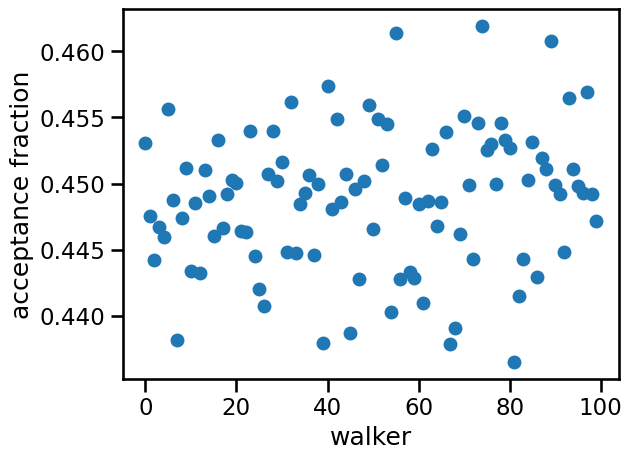

In [26]:
plt.plot(result_emcee.acceptance_fraction, "o")
plt.xlabel("walker")
plt.ylabel("acceptance fraction")



In [27]:
if hasattr(result_emcee, "acor"):
    print("Autocorrelation time for the parameters:")
    print("----------------------------------------")
    for i, p in enumerate(result_emcee.params):
        try:
            print(f"{p} = {result_emcee.acor[i]:.3f}")
        except IndexError:
            pass

Autocorrelation time for the parameters:
----------------------------------------
r0 = 127.701
sig2 = 126.739
m = 113.955
s0 = 100.448
noise = 136.988


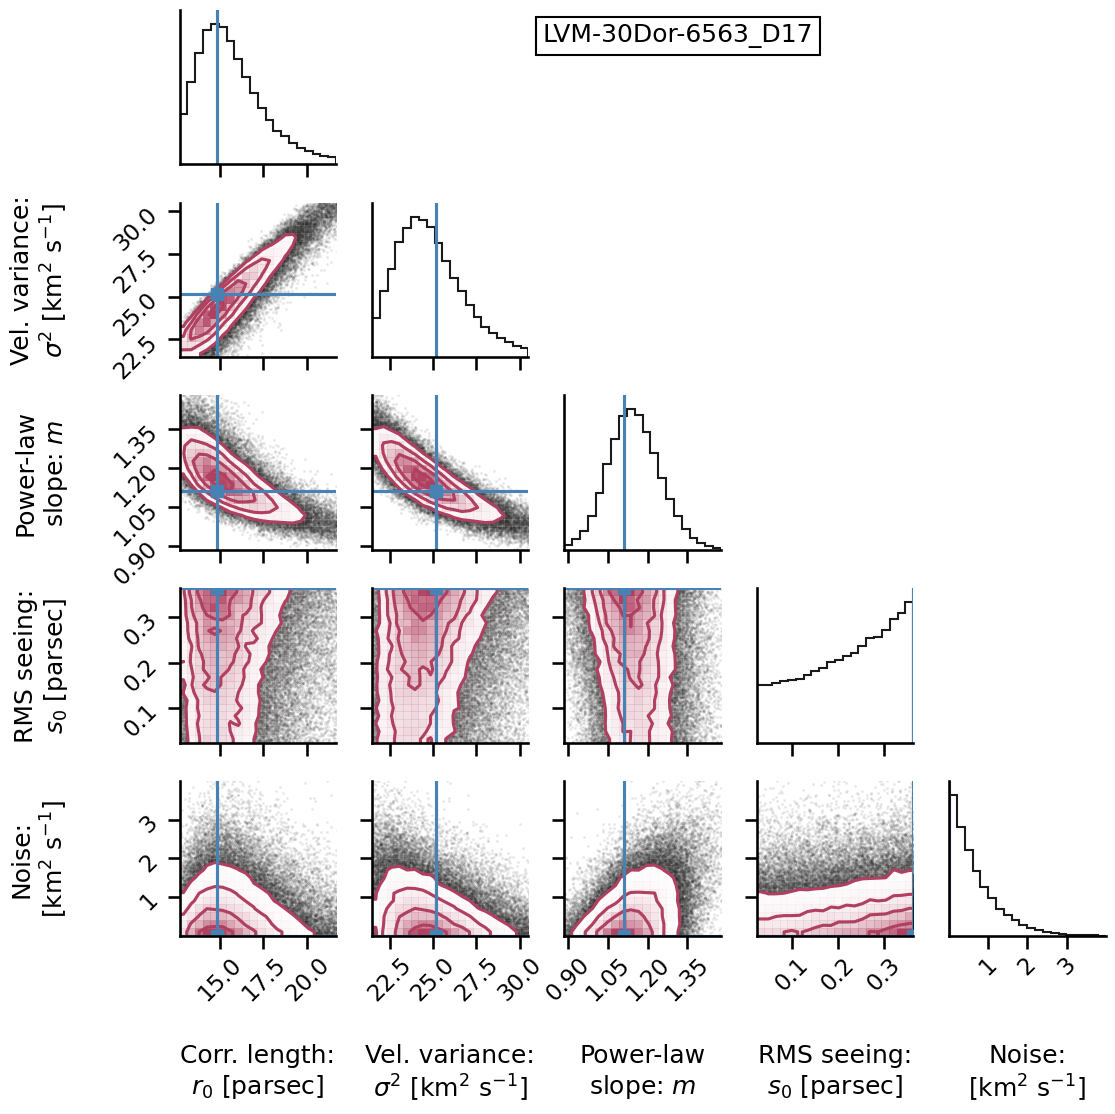

In [28]:
bplot.corner_plot(
    result_emcee, result, name, data, data_ranges=[0.95, 0.95, 0.995, 0.999, 0.999]
)

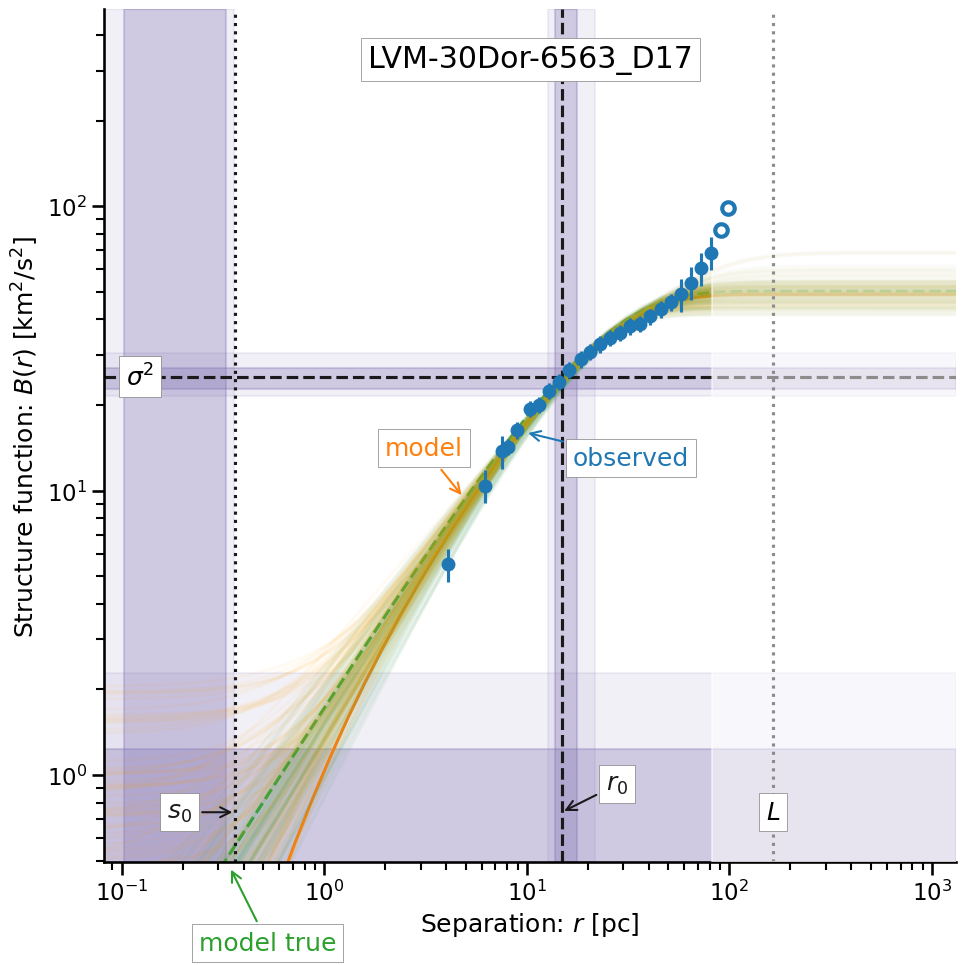

In [29]:
bplot.STYLE["data label element"] = 4
bplot.STYLE["model label element"] = 0
bplot.STYLE["model label offset"] = (-60, 40)
bplot.STYLE["true model label element"] = 7
bplot.STYLE["true model label offset"] = (30, -60)
bplot.strucfunc_plot(
    result_emcee, result, r, B, to_fit, name, data, box_size, large_scale
)

In [30]:
LM = {
    'sig2': [result.params['sig2'].value,result.params['sig2'].stderr],
    'r0': [result.params['r0'].value,result.params['r0'].stderr],
    'm' : [result.params['m'].value,result.params['m'].stderr],
    's0': [result.params['s0'].value,result.params['s0'].stderr],
    'noise' : [result.params['noise'].value,result.params['noise'].stderr]
}

In [31]:
MCMC = {
    'sig2': [result_emcee.params['sig2'].value,result_emcee.params['sig2'].stderr],
    'r0': [result_emcee.params['r0'].value,result_emcee.params['r0'].stderr],
    'm' : [result_emcee.params['m'].value,result_emcee.params['m'].stderr],
    's0': [result_emcee.params['s0'].value,result_emcee.params['s0'].stderr],
    'noise' : [result_emcee.params['noise'].value,result_emcee.params['noise'].stderr]
}

In [32]:
sig2s2 = np.percentile(result_emcee.flatchain['sig2'],[2.5, 97.5])
r0s2 = np.percentile(result_emcee.flatchain['r0'],[2.5, 97.5])
ms2 = np.percentile(result_emcee.flatchain['m'],[2.5, 97.5])
s0s2 = np.percentile(result_emcee.flatchain['s0'],[2.5, 97.5])
b0s2 = np.percentile(result_emcee.flatchain['noise'],[2.5, 97.5])

In [33]:
sig2s2p = sig2s2[1]-result.params['sig2'].value
sig2s2m = result.params['sig2'].value-sig2s2[0]

r0s2p = r0s2[1]-result.params['r0'].value
r0s2m = result.params['r0'].value-r0s2[0]

ms2p = ms2[1]-result.params['m'].value
ms2m = result.params['m'].value-ms2[0]

s0s2p = s0s2[1]-result.params['s0'].value
s0s2m = result.params['s0'].value-s0s2[0]

b0s2p = b0s2[1]-result.params['noise'].value
b0s2m = result.params['noise'].value-b0s2[0]

In [34]:
# MCMC 1 sigma confidence interval

sig2s1 = np.percentile(result_emcee.flatchain['sig2'],[16, 85])
r0s1 = np.percentile(result_emcee.flatchain['r0'],[16, 85])
ms1 = np.percentile(result_emcee.flatchain['m'],[16, 85])
s0s1 = np.percentile(result_emcee.flatchain['s0'],[16, 85])
b0s1 = np.percentile(result_emcee.flatchain['noise'],[16, 85])

sig2s1p = sig2s1[1]-result.params['sig2'].value
sig2s1m = result.params['sig2'].value-sig2s1[0]

r0s1p = r0s1[1]-result.params['r0'].value
r0s1m = result.params['r0'].value-r0s1[0]

ms1p = ms1[1]-result.params['m'].value
ms1m = result.params['m'].value-ms1[0]

s0s1p = s0s1[1]-result.params['s0'].value
s0s1m = result.params['s0'].value-s0s1[0]

b0s1p = b0s1[1]-result.params['noise'].value
b0s1m = result.params['noise'].value-b0s1[0]

In [35]:
#  LM + MCMC 2 sigma

results_2sig = {
    'sig2': [result.params['sig2'].value,sig2s2p,sig2s2m],
    'r0': [result.params['r0'].value,r0s2p,r0s2m],
    'm' : [result.params['m'].value,ms2p,ms2m],
    's0': [result.params['s0'].value,s0s2p,s0s2m],
    'noise' : [result.params['noise'].value,b0s2p,b0s2m] 
    
}

results_2sig

{'sig2': [25.13729443019403, 5.37559740488307, 3.68743792197548],
 'r0': [14.854729252067338, 6.778165699110508, 2.132608283222943],
 'm': [1.1092583471188897, 0.2506961390867881, 0.14831309576590368],
 's0': [0.36361026082145803, -0.0052710292565691375, 0.3267270178721656],
 'noise': [2.544312604902605e-10, 2.275449357113418, -0.018281088292024055]}

# Diagnostic

In [36]:
import importlib
importlib.reload(fdu)

<module 'fit_diagnostic_utils' from '/Users/javier/LVM_30dor/subfields_subrot/r50pc-HI-6563/py_modules/fit_diagnostic_utils.py'>

In [37]:
params_to_check = ["r0", "sig2", "m", "s0", "noise"]

bound_flags = fdu.get_bound_flags(
    result.params,
    param_names=params_to_check,
    frac=0.05,
)

# Use a relative bound criterion for r0 because its allowed range is wide
bound_flags["r0"] = fdu.near_bound_relative(
    result.params["r0"],
    lower_factor=1.5,
    upper_fraction=0.9,
)

bound_flags

{'r0': False, 'sig2': False, 'm': False, 's0': True, 'noise': True}

In [38]:
n_params_near_bounds = sum(bound_flags.values())

n_params_near_bounds

2

In [39]:
# Fractional uncertainty diagnostics from 2-sigma MCMC intervals

r0_frac_uncertainty = fdu.frac_uncertainty(
    value=results_2sig["r0"][0],
    err_plus=results_2sig["r0"][1],
    err_minus=results_2sig["r0"][2],
)

sig2_frac_uncertainty = fdu.frac_uncertainty(
    value=results_2sig["sig2"][0],
    err_plus=results_2sig["sig2"][1],
    err_minus=results_2sig["sig2"][2],
)

s0_frac_uncertainty = fdu.frac_uncertainty(
    value=results_2sig["s0"][0],
    err_plus=results_2sig["s0"][1],
    err_minus=results_2sig["s0"][2],
)

noise_frac_uncertainty = fdu.frac_uncertainty(
    value=results_2sig["noise"][0],
    err_plus=results_2sig["noise"][1],
    err_minus=results_2sig["noise"][2],
)

m_abs_uncertainty = max(
    abs(results_2sig["m"][1]),
    abs(results_2sig["m"][2]),
)

In [40]:
r0_frac_uncertainty, sig2_frac_uncertainty, s0_frac_uncertainty, noise_frac_uncertainty, m_abs_uncertainty

(0.4562968186153368,
 0.21384948248153918,
 0.8985638005210116,
 8943277460.202345,
 0.2506961390867881)

In [41]:
# Uncertainty quality flags

uncertainty_flags = {}

uncertainty_flags["large_r0_uncertainty"] = r0_frac_uncertainty > 0.5
uncertainty_flags["large_sig2_uncertainty"] = sig2_frac_uncertainty > 0.5
uncertainty_flags["large_s0_uncertainty"] = s0_frac_uncertainty > 0.75
uncertainty_flags["large_noise_uncertainty"] = noise_frac_uncertainty > 1.0
uncertainty_flags["large_m_uncertainty"] = m_abs_uncertainty > 0.3

uncertainty_flags

{'large_r0_uncertainty': False,
 'large_sig2_uncertainty': False,
 'large_s0_uncertainty': True,
 'large_noise_uncertainty': True,
 'large_m_uncertainty': False}

In [42]:
n_large_uncertainties = sum(uncertainty_flags.values())

n_large_uncertainties

2

In [43]:
# Reduced chi-square quality flags

redchi_flags = {}

redchi_flags["redchi_too_low"] = result.redchi < 0.3
redchi_flags["redchi_too_high"] = result.redchi > 1.2

redchi_flags

{'redchi_too_low': False, 'redchi_too_high': False}

In [44]:
# Physical / interpretive diagnostics

r_fit_max = np.max(r[to_fit])
n_fit_points = np.sum(to_fit)

r0_value = result.params["r0"].value
s0_value = result.params["s0"].value
noise_value = result.params["noise"].value

r0_over_rfitmax = r0_value / r_fit_max
s0_arcsec = s0_value / pc_per_arcsec

n_small = min(3, np.sum(to_fit))
B_small = np.median(B[to_fit][:n_small])
noise_fraction = noise_value / B_small

physical_flags = {}

physical_flags["r0_larger_than_fit_range"] = r0_over_rfitmax > 1.0
physical_flags["r0_much_larger_than_fit_range"] = r0_over_rfitmax > 2.0
physical_flags["large_s0_arcsec"] = s0_arcsec > 1.2
physical_flags["large_noise_fraction"] = noise_fraction > 0.5

physical_flags

{'r0_larger_than_fit_range': False,
 'r0_much_larger_than_fit_range': False,
 'large_s0_arcsec': True,
 'large_noise_fraction': False}

In [45]:
r_fit_max, r0_over_rfitmax, s0_arcsec, noise_fraction

(81.33181441155183,
 0.18264352467166245,
 1.4999999999558844,
 2.4431330248812886e-11)

In [46]:
fdu.max_run_same_sign([1, 2, -1, -3, -4, 2])

3

In [47]:
# Residual-pattern diagnostic

B_model = result.eval(r=r)

residuals = B - B_model
residuals_fit = residuals[to_fit]

max_residual_run = fdu.max_run_same_sign(residuals_fit)

max_residual_run

10

In [48]:
residual_flags = {}

residual_flags["systematic_residuals"] = max_residual_run >= 4

residual_flags

{'systematic_residuals': True}

In [49]:
# Collect all diagnostic flags

all_flags = {}

all_flags.update(bound_flags)
all_flags.update(uncertainty_flags)
all_flags.update(redchi_flags)
all_flags.update(physical_flags)
all_flags.update(residual_flags)

all_flags

{'r0': False,
 'sig2': False,
 'm': False,
 's0': True,
 'noise': True,
 'large_r0_uncertainty': False,
 'large_sig2_uncertainty': False,
 'large_s0_uncertainty': True,
 'large_noise_uncertainty': True,
 'large_m_uncertainty': False,
 'redchi_too_low': False,
 'redchi_too_high': False,
 'r0_larger_than_fit_range': False,
 'r0_much_larger_than_fit_range': False,
 'large_s0_arcsec': True,
 'large_noise_fraction': False,
 'systematic_residuals': True}

In [50]:
# Rename bound flags for clarity

bound_flags_named = {
    f"{param_name}_near_bound": value
    for param_name, value in bound_flags.items()
}

bound_flags_named

{'r0_near_bound': False,
 'sig2_near_bound': False,
 'm_near_bound': False,
 's0_near_bound': True,
 'noise_near_bound': True}

In [51]:
# Collect all diagnostic flags

all_flags = {}

all_flags.update(bound_flags_named)
all_flags.update(uncertainty_flags)
all_flags.update(redchi_flags)
all_flags.update(physical_flags)
all_flags.update(residual_flags)

all_flags

{'r0_near_bound': False,
 'sig2_near_bound': False,
 'm_near_bound': False,
 's0_near_bound': True,
 'noise_near_bound': True,
 'large_r0_uncertainty': False,
 'large_sig2_uncertainty': False,
 'large_s0_uncertainty': True,
 'large_noise_uncertainty': True,
 'large_m_uncertainty': False,
 'redchi_too_low': False,
 'redchi_too_high': False,
 'r0_larger_than_fit_range': False,
 'r0_much_larger_than_fit_range': False,
 'large_s0_arcsec': True,
 'large_noise_fraction': False,
 'systematic_residuals': True}

In [52]:
active_flags = [key for key, value in all_flags.items() if value]

active_flags

['s0_near_bound',
 'noise_near_bound',
 'large_s0_uncertainty',
 'large_noise_uncertainty',
 'large_s0_arcsec',
 'systematic_residuals']

In [53]:
# Diagnostic quality score

quality_score = 0

# Reduced chi-square flags
if all_flags["redchi_too_low"]:
    quality_score += 1

if all_flags["redchi_too_high"]:
    quality_score += 2

# Bound flags
if all_flags["r0_near_bound"]:
    quality_score += 2

if all_flags["sig2_near_bound"]:
    quality_score += 1

if all_flags["m_near_bound"]:
    quality_score += 2

if all_flags["s0_near_bound"]:
    quality_score += 2

if all_flags["noise_near_bound"]:
    quality_score += 1

# Uncertainty flags
if all_flags["large_r0_uncertainty"]:
    quality_score += 2

if all_flags["large_sig2_uncertainty"]:
    quality_score += 1

if all_flags["large_s0_uncertainty"]:
    quality_score += 1

if all_flags["large_noise_uncertainty"]:
    quality_score += 1

if all_flags["large_m_uncertainty"]:
    quality_score += 2

# Physical / interpretive flags
if all_flags["r0_larger_than_fit_range"]:
    quality_score += 1

if all_flags["r0_much_larger_than_fit_range"]:
    quality_score += 2

if all_flags["large_s0_arcsec"]:
    quality_score += 2

if all_flags["large_noise_fraction"]:
    quality_score += 2

# Residual-pattern flag
if all_flags["systematic_residuals"]:
    quality_score += 2

quality_score

9

In [54]:
# Diagnostic quality class

if quality_score <= 1:
    quality_class = "A"
elif quality_score <= 3:
    quality_class = "B"
elif quality_score <= 6:
    quality_class = "C"
else:
    quality_class = "D"

quality_class

'D'

In [55]:
# Diagnostic summary for current fit

diagnostics = {
    # Basic identifiers
    "name": name,
#    "data": data,
#    "line": line,
#    "binsize": binsize,

    # Fit setup
    "box_size": box_size,
    "pc_per_arcsec": pc_per_arcsec,
    "n_fit_points": n_fit_points,
    "relative_uncertainty": relative_uncertainty,

    # Fit quality
    "redchi": result.redchi,
    "quality_score": quality_score,
    "quality_class": quality_class,

    # Best-fit parameters
    "r0": result.params["r0"].value,
    "sig2": result.params["sig2"].value,
    "m": result.params["m"].value,
    "s0": result.params["s0"].value,
    "noise": result.params["noise"].value,

    # Interpretive diagnostics
    "r_fit_max": r_fit_max,
    "r0_over_rfitmax": r0_over_rfitmax,
    "s0_arcsec": s0_arcsec,
    "noise_fraction": noise_fraction,

    # Uncertainty diagnostics
    "r0_frac_uncertainty": r0_frac_uncertainty,
    "sig2_frac_uncertainty": sig2_frac_uncertainty,
    "s0_frac_uncertainty": s0_frac_uncertainty,
    "noise_frac_uncertainty": noise_frac_uncertainty,
    "m_abs_uncertainty": m_abs_uncertainty,

    # Residual diagnostics
    "max_residual_run": max_residual_run,

    # Flags
    "n_active_flags": len(active_flags),
    "active_flags": "; ".join(active_flags),
}

diagnostics

{'name': 'LVM-30Dor-6563_D17',
 'box_size': 164.26997627942373,
 'pc_per_arcsec': 0.24240684055476797,
 'n_fit_points': 24,
 'relative_uncertainty': 0.06612499999999999,
 'redchi': 0.9147657398935356,
 'quality_score': 9,
 'quality_class': 'D',
 'r0': 14.854729252067338,
 'sig2': 25.13729443019403,
 'm': 1.1092583471188897,
 's0': 0.36361026082145803,
 'noise': 2.544312604902605e-10,
 'r_fit_max': 81.33181441155183,
 'r0_over_rfitmax': 0.18264352467166245,
 's0_arcsec': 1.4999999999558844,
 'noise_fraction': 2.4431330248812886e-11,
 'r0_frac_uncertainty': 0.4562968186153368,
 'sig2_frac_uncertainty': 0.21384948248153918,
 's0_frac_uncertainty': 0.8985638005210116,
 'noise_frac_uncertainty': 8943277460.202345,
 'm_abs_uncertainty': 0.2506961390867881,
 'max_residual_run': 10,
 'n_active_flags': 6,
 'active_flags': 's0_near_bound; noise_near_bound; large_s0_uncertainty; large_noise_uncertainty; large_s0_arcsec; systematic_residuals'}

In [56]:
diagnostics_df = pd.DataFrame([diagnostics])

diagnostics_df

,name,box_size,pc_per_arcsec,n_fit_points,relative_uncertainty,redchi,quality_score,quality_class,r0,sig2,...,s0_arcsec,noise_fraction,r0_frac_uncertainty,sig2_frac_uncertainty,s0_frac_uncertainty,noise_frac_uncertainty,m_abs_uncertainty,max_residual_run,n_active_flags,active_flags
0,LVM-30Dor-6563_D17,164.269976,0.242407,24,0.066125,0.914766,9,D,14.854729,25.137294,...,1.5,2.443133e-11,0.456297,0.213849,0.898564,8.943277e+09,0.250696,10,6,s0_near_bound; noise_near_bound; large_s0_unce...


In [57]:
diagnostics_df[[
    "name",
    "redchi",
    "quality_score",
    "quality_class",
    "r0_over_rfitmax",
    "s0_arcsec",
    "noise_fraction",
    "max_residual_run",
    "n_active_flags",
    "active_flags",
]]

,name,redchi,quality_score,quality_class,r0_over_rfitmax,s0_arcsec,noise_fraction,max_residual_run,n_active_flags,active_flags
0,LVM-30Dor-6563_D17,0.914766,9,D,0.182644,1.5,2.443133e-11,10,6,s0_near_bound; noise_near_bound; large_s0_unce...


In [58]:
# Add individual diagnostic flag columns to diagnostics_df

for flag_name, flag_value in all_flags.items():
    diagnostics_df[flag_name] = flag_value

diagnostics_df

,name,box_size,pc_per_arcsec,n_fit_points,relative_uncertainty,redchi,quality_score,quality_class,r0,sig2,...,large_s0_uncertainty,large_noise_uncertainty,large_m_uncertainty,redchi_too_low,redchi_too_high,r0_larger_than_fit_range,r0_much_larger_than_fit_range,large_s0_arcsec,large_noise_fraction,systematic_residuals
0,LVM-30Dor-6563_D17,164.269976,0.242407,24,0.066125,0.914766,9,D,14.854729,25.137294,...,True,True,False,False,False,False,False,True,False,True


In [59]:
flag_columns = list(all_flags.keys())

diagnostics_df[["name", "quality_class", "quality_score"] + flag_columns]

,name,quality_class,quality_score,r0_near_bound,sig2_near_bound,m_near_bound,s0_near_bound,noise_near_bound,large_r0_uncertainty,large_sig2_uncertainty,large_s0_uncertainty,large_noise_uncertainty,large_m_uncertainty,redchi_too_low,redchi_too_high,r0_larger_than_fit_range,r0_much_larger_than_fit_range,large_s0_arcsec,large_noise_fraction,systematic_residuals
0,LVM-30Dor-6563_D17,D,9,False,False,False,True,True,False,False,True,True,False,False,False,False,False,True,False,True


In [60]:
from pathlib import Path

diagnostics_csv_path = Path("fits_ready/fit_diagnostics_summary.csv")

if diagnostics_csv_path.exists():
    diagnostics_all_df = pd.read_csv(diagnostics_csv_path)

    # Remove previous entry for the same run/sample
    diagnostics_all_df = diagnostics_all_df[
        diagnostics_all_df["name"] != diagnostics_df.loc[0, "name"]
    ]

    # Add the updated row
    diagnostics_all_df = pd.concat(
        [diagnostics_all_df, diagnostics_df],
        ignore_index=True,
    )

else:
    diagnostics_all_df = diagnostics_df.copy()

# Optional: sort alphabetically by sample name
diagnostics_all_df = diagnostics_all_df.sort_values("name").reset_index(drop=True)

# Save updated cumulative table
diagnostics_all_df.to_csv(diagnostics_csv_path, index=False)

diagnostics_all_df.tail()

,name,box_size,pc_per_arcsec,n_fit_points,relative_uncertainty,redchi,quality_score,quality_class,r0,sig2,...,large_s0_uncertainty,large_noise_uncertainty,large_m_uncertainty,redchi_too_low,redchi_too_high,r0_larger_than_fit_range,r0_much_larger_than_fit_range,large_s0_arcsec,large_noise_fraction,systematic_residuals
33,LVM-30Dor-6563_D5,165.071308,0.242407,26,0.050000,0.892636,9,D,36.155799,61.427243,...,True,True,False,False,False,False,False,True,False,True
34,LVM-30Dor-6563_D6,165.350764,0.242407,26,0.202278,0.785119,14,D,30.824579,50.422862,...,True,True,True,False,False,False,False,True,False,True
35,LVM-30Dor-6563_D7,167.120571,0.242407,26,0.115653,0.760922,9,D,14.429146,56.052211,...,True,True,False,False,False,False,False,True,False,True
36,LVM-30Dor-6563_D8,166.384914,0.242407,26,0.066125,0.802210,7,D,17.277873,99.964829,...,True,True,False,False,False,False,False,False,False,True
37,LVM-30Dor-6563_D9,166.321665,0.242407,21,0.050000,0.883005,12,D,42.023507,366.082447,...,True,True,False,False,False,False,False,True,False,True


In [61]:
# Read cumulative diagnostics table

diagnostics_all_df = pd.read_csv(diagnostics_csv_path)

review_columns = [
    "name",
    "quality_class",
    "quality_score",
    "redchi",
    "r0_over_rfitmax",
    "s0_arcsec",
    "noise_fraction",
    "max_residual_run",
    "n_active_flags",
    "active_flags",
]

review_df = diagnostics_all_df[review_columns].copy()

review_df

,name,quality_class,quality_score,redchi,r0_over_rfitmax,s0_arcsec,noise_fraction,max_residual_run,n_active_flags,active_flags
0,LVM-30Dor-6563_A,D,9,0.903346,0.161363,0.100000,2.884545e-01,8,5,m_near_bound; s0_near_bound; large_s0_uncertai...
1,LVM-30Dor-6563_B1,C,6,0.787893,0.098646,0.100000,1.273463e-01,4,4,s0_near_bound; large_s0_uncertainty; large_noi...
2,LVM-30Dor-6563_B2,D,9,0.678354,0.161672,1.500000,7.703418e-02,4,6,s0_near_bound; noise_near_bound; large_s0_unce...
3,LVM-30Dor-6563_B3,D,8,0.748781,0.180072,1.500000,1.307237e-01,5,5,s0_near_bound; large_s0_uncertainty; large_noi...
4,LVM-30Dor-6563_B4,D,12,0.531988,0.964978,1.500000,2.917766e-11,8,8,s0_near_bound; noise_near_bound; large_r0_unce...
5,LVM-30Dor-6563_B5,D,14,0.765202,0.246199,1.500000,2.562296e-08,8,9,s0_near_bound; noise_near_bound; large_r0_unce...
6,LVM-30Dor-6563_B6,D,11,0.932811,0.097035,1.500000,1.025388e-01,5,7,sig2_near_bound; s0_near_bound; large_s0_uncer...
7,LVM-30Dor-6563_B7,D,9,0.548805,0.126835,1.500000,1.160369e-11,6,6,s0_near_bound; noise_near_bound; large_s0_unce...
8,LVM-30Dor-6563_C1,D,16,0.777968,2.023180,1.500000,2.826893e-02,10,10,r0_near_bound; s0_near_bound; noise_near_bound...
9,LVM-30Dor-6563_C10,D,12,0.893776,0.556483,1.499997,2.651904e-11,10,8,s0_near_bound; noise_near_bound; large_r0_unce...


In [62]:
review_df_sorted = review_df.sort_values(
    by=["quality_score", "n_active_flags"],
    ascending=False,
).reset_index(drop=True)

review_df_sorted

,name,quality_class,quality_score,redchi,r0_over_rfitmax,s0_arcsec,noise_fraction,max_residual_run,n_active_flags,active_flags
0,LVM-30Dor-6563_C1,D,16,0.777968,2.023180,1.500000,2.826893e-02,10,10,r0_near_bound; s0_near_bound; noise_near_bound...
1,LVM-30Dor-6563_D11,D,16,0.996618,2.039104,1.499997,3.059647e-01,10,10,r0_near_bound; s0_near_bound; large_r0_uncerta...
2,LVM-30Dor-6563_D3,D,15,0.876233,1.986554,1.499933,5.492081e-01,8,9,r0_near_bound; s0_near_bound; large_r0_uncerta...
3,LVM-30Dor-6563_B5,D,14,0.765202,0.246199,1.500000,2.562296e-08,8,9,s0_near_bound; noise_near_bound; large_r0_unce...
4,LVM-30Dor-6563_C6,D,14,0.933376,0.129331,1.500000,2.555293e-06,6,9,s0_near_bound; noise_near_bound; large_r0_unce...
5,LVM-30Dor-6563_D6,D,14,0.785119,0.378998,1.500000,1.194964e-09,9,9,s0_near_bound; noise_near_bound; large_r0_unce...
6,LVM-30Dor-6563_D14,D,13,0.770699,1.126035,1.499970,2.127761e-11,9,9,s0_near_bound; noise_near_bound; large_r0_unce...
7,LVM-30Dor-6563_B4,D,12,0.531988,0.964978,1.500000,2.917766e-11,8,8,s0_near_bound; noise_near_bound; large_r0_unce...
8,LVM-30Dor-6563_C10,D,12,0.893776,0.556483,1.499997,2.651904e-11,10,8,s0_near_bound; noise_near_bound; large_r0_unce...
9,LVM-30Dor-6563_C3,D,12,0.809339,0.401187,1.500000,2.812950e-11,7,8,s0_near_bound; noise_near_bound; large_r0_unce...


In [63]:

review_csv_path = Path("fits_ready") / "fit_diagnostics_short.csv"

review_df_sorted.to_csv(review_csv_path, index=False)

review_csv_path

PosixPath('fits_ready/fit_diagnostics_short.csv')

# Export

In [64]:
#save_modelresult(result, "results_fit/" + name + "result_ideal.sav")
#save_modelresult(result_emcee, "results_fit/" + name + "result_emcee_ideal.sav")

In [65]:
df = pd.DataFrame(results_2sig)

# Flatten MultiIndex columns
if isinstance(df.columns, pd.MultiIndex):
    df.columns = ["_".join(map(str, col)).strip() for col in df.columns.to_flat_index()]
else:
    df.columns = [str(c) for c in df.columns]

df = df.reset_index(drop=True)

t = Table.from_pandas(df)
new_hdu = fits.BinTableHDU(t, name="PARAMETERS")

with fits.open(fits_path, memmap=False) as hdul:
    hdus = [h.copy() for h in hdul]

# FITS EXTNAMEs are effectively case-insensitive; astropy reports them uppercase.
target = "PARAMETERS"
idxs = [i for i, h in enumerate(hdus) if h.name.upper() == target]

if idxs:
    i0 = idxs[0]
    # Optional: preserve existing header cards (metadata) from old PARAMETERS
    old_hdr = hdus[i0].header.copy()
    hdus[i0] = new_hdu
    # Keep old metadata, then ensure EXTNAME stays correct
    hdus[i0].header.update(old_hdr)
    hdus[i0].name = target
    # Remove any additional duplicates if they exist
    for j in reversed(idxs[1:]):
        del hdus[j]
else:
    # If it doesn't exist, add it
    hdus.append(new_hdu)

fits.HDUList(hdus).writeto(fits_path, overwrite=True)

In [66]:
# Test import

from astropy.table import Table
t = Table.read(fits_path, hdu="PARAMETERS")
df_loaded = t.to_pandas()
df_loaded

,sig2,r0,m,s0,noise
0,25.137294,14.854729,1.109258,0.363610,2.544313e-10
1,5.375597,6.778166,0.250696,-0.005271,2.275449e+00
2,3.687438,2.132608,0.148313,0.326727,-1.828109e-02


In [67]:
with fits.open(fits_path) as hdul:
    hdul.info()

Filename: fits_ready/LVM-30Dor-6563_D17.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      29   ()      
  1  LVM-30DOR-6563_D17    1 BinTableHDU     23   986R x 7C   [D, D, D, D, D, D, D]   
  2  TABLE         1 BinTableHDU     19   31R x 5C   [D, D, D, D, D]   
  3  PARAMETERS    1 BinTableHDU     19   3R x 5C   [D, D, D, D, D]   


In [68]:
print("--- %s seconds ---" % (time.time() - start_time))

--- 101.17418193817139 seconds ---
